# Classification Project

A classification algorithm is a machine learning method used to categorize data into different classes or groups. It learns patterns from the training data and then predicts the correct class for new data.
In classification problems, the output variable is categorical, meaning it belongs to specific categories. For example, in the heart disease dataset, the target variable HeartDisease has two classes: 0 (no disease) and 1 (disease).
Classification algorithms analyze the input features and determine which category the data belongs to. Some common classification algorithms include Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Decision Tree, Random Forest, and Naive Bayes.

**Explain The Dataset**

The dataset is used to predict heart disease in patients. It contains 918 patient records and 12 columns. There are 11 input features and 1 target variable. The target variable is HeartDisease, which indicates whether a patient has heart disease or not. A value of 1 means the patient has heart disease, and 0 means the patient does not have heart disease. The dataset includes medical attributes such as age, sex, chest pain type, blood pressure, cholesterol level, heart rate, and other clinical measurements. These features help analyze the health condition of patients. The dataset is commonly used in machine learning to build classification models for predicting heart disease. The main objective is to develop models that can accurately identify patients who are at risk of heart disease.

**EDA(Exploratory Data Analysis)**

Basic EDA (Exploratory Data Analysis) is the process of examining and understanding the dataset before applying machine learning models. It helps to identify patterns, relationships, and possible issues in the data.
In basic EDA, the dataset is first loaded and inspected using functions like head(), info(), and describe().

In [1]:
#IMPORT NECESSARY LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# CLEANING THE DATA
df=pd.read_csv("C:/Users/HP/Downloads/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# This code is standardizing column names so they are easier to work with in Python.
df.columns=df.columns.str.replace("-","_")
df.columns=df.columns.str.replace(" ","_")
df.columns=df.columns.str.capitalize()
df.columns

Index(['Age', 'Sex', 'Chestpaintype', 'Restingbp', 'Cholesterol', 'Fastingbs',
       'Restingecg', 'Maxhr', 'Exerciseangina', 'Oldpeak', 'St_slope',
       'Heartdisease'],
      dtype='object')

In [4]:
# Find the missing values and Replace the values
df.isnull().sum()

Age               0
Sex               0
Chestpaintype     0
Restingbp         0
Cholesterol       0
Fastingbs         0
Restingecg        0
Maxhr             0
Exerciseangina    0
Oldpeak           0
St_slope          0
Heartdisease      0
dtype: int64

In [5]:
#  DUPLICATES values in the dataset,drop the duplicates values (156)
df.duplicated().sum()
# drop the duplicates 
df.drop_duplicates(inplace=True)


In [6]:
# information of dataset 
df.info

<bound method DataFrame.info of      Age Sex Chestpaintype  Restingbp  Cholesterol  Fastingbs Restingecg  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     Maxhr Exerciseangina  Oldpeak St_slope  Heartdisea

In [7]:
# MAKE A STATISTICAL SUMMARY of dataset
df.describe()

,Age,Restingbp,Cholesterol,Fastingbs,Maxhr,Oldpeak,Heartdisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
# Returns the dimensions of a DataFrame
df.shape

(918, 12)

In [10]:
# returns coorelationn of the dataset
df.corr

<bound method DataFrame.corr of      Age Sex Chestpaintype  Restingbp  Cholesterol  Fastingbs Restingecg  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     Maxhr Exerciseangina  Oldpeak St_slope  Heartdisea

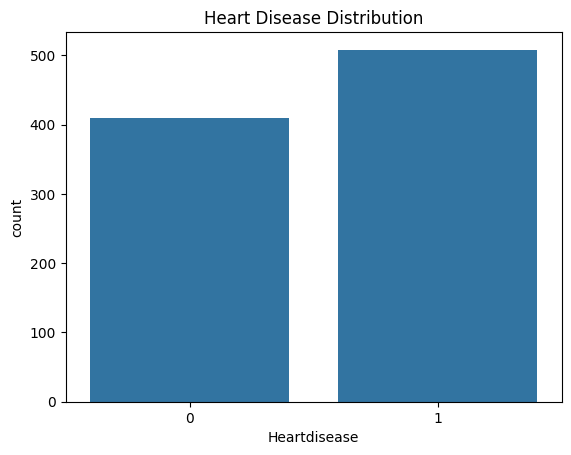

In [ ]:
# Target Distribution
import seaborn as sns
sns.countplot(x='Heartdisease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

**Encode Categorical Data**

In [ ]:
# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Some columns contain text values.
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Correlation Matrix (Collinearity)**

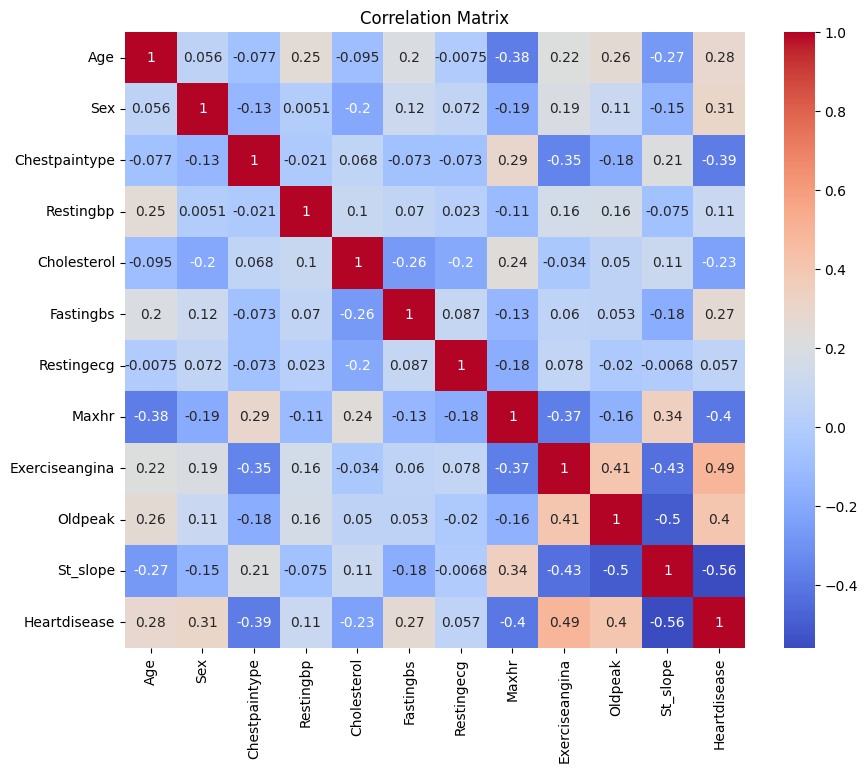

In [ ]:
# Collinearity Matrix (Correlation Matrix)
# This matrix helps identify multicollinearity between variables.
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
# This helps detect multicollinearity.

**Split the Dataset**

In [ ]:
# The dataset is divided into training data and testing data
from sklearn.model_selection import train_test_split
X = df.drop("Heartdisease", axis=1)
y = df["Heartdisease"]
# Usually 80% training and 20% testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Classification Algorithms


We will train 6 algorithms:

1.Logistic Regression

2.K-Nearest Neighbors

3.Support Vector Machine

4.Decision Tree

5.Random Forest

6.Naive Bayes

# Logistic Regression

Logistic Regression is a classification algorithm used to predict binary outcomes. It estimates the probability that a data point belongs to a particular class. It is commonly used for problems where the output has two categories, such as predicting whether a patient has heart disease or not.

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.8478260869565217


**Hypertuning of parameters for the best fit model**

Hyperparameter tuning (hypertuning) is the process of selecting the best configuration of parameters so that a machine learning model performs optimally on unseen data

In [ ]:
# Hypertuning of parameters for the best fit model
from sklearn.model_selection import GridSearchCV
model = LogisticRegression()
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [300, 500, 1000]}
# Best parameters
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2)
grid_search.fit(X_train, y_train)
# Best Mode
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
#accuracy
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'C': 1, 'max_iter': 300, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.8555772994129158


# K-Nearest Neighbors (KNN)

KNN is a simple algorithm that classifies data based on the closest data points in the dataset. It finds the K nearest neighbors and assigns the class that is most common among them. It works well for pattern recognition problems.

In [ ]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)
print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.8478260869565217


**Hypertuning of parameters for the best fit model**

Classifies a data point based on the majority class of its nearest neighbors

In [ ]:
# Model
model = KNeighborsClassifier()

# Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9],#(1,3)Overfitting,(5, 7)Balanced,(9, 11)Underfitting
    'weights': ['uniform', 'distance'],#All neighbors equal	,#Closer neighbors matter more
    'metric': ['euclidean', 'manhattan']#Distance calculation method
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Test accuracy
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Test Accuracy: 0.8913043478260869


# Support Vector Machine (SVM)

SVM is a powerful classification algorithm that separates data into different classes using a boundary called a hyperplane. It tries to find the best boundary that maximizes the distance between different classes.

In [ ]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)
print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.8641304347826086


**Hypertuning of parameters for the best fit model**

In [ ]:
# Model
model = SVC()

# Parameter grid
param_grid = {
    'C': [0.1, 1, 10], #C: explore underfit- balanced - overfit
    'kernel': ['linear', 'rbf'],#kernel: compare linear vs nonlinear
    'gamma': ['scale', 'auto'] #gamma: control flexibility
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Test accuracy
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Test Accuracy: 0.8641304347826086


# Decision Tree

Decision Tree is a model that makes decisions based on a tree-like structure. It splits the dataset into branches using feature conditions. Each branch represents a decision, and the final leaf node represents the predicted class.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.8097826086956522


# Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees. Each tree makes a prediction, and the final result is based on the majority vote. It improves accuracy and reduces overfitting

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.875


**Hypertuning of parameters for the best fit model**

In [ ]:
# Model
model = RandomForestClassifier()

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 10],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train model
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Test accuracy
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 100}
Test Accuracy: 0.8967391304347826


# Naive Bayes

Naive Bayes is a probabilistic classification algorithm based on Bayes’ theorem. It assumes that features are independent of each other. It is fast, simple, and often performs well for classification tasks.

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, pred_nb)
print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.842391304347826


**Hypertuning of parameters for the best fit model**

Naive Bayes is a probabilistic algorithm based on Bayes' Theorem

In [ ]:
# Model
model = GaussianNB()

# Hyperparameter grid
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# Train
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Test accuracy
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'var_smoothing': 1e-09}
Test Accuracy: 0.842391304347826


**Calculating all algorithm accuracy score  taking  which is best model for the dataset**

In [ ]:
results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Naive Bayes'
    ],
    'Accuracy': [
        acc_lr,
        acc_knn,
        acc_svm,
        acc_dt,
        acc_rf,
        acc_nb
    ]
})

print(results)

             Algorithm  Accuracy
0  Logistic Regression  0.847826
1                  KNN  0.847826
2                  SVM  0.864130
3        Decision Tree  0.809783
4        Random Forest  0.875000
5          Naive Bayes  0.842391


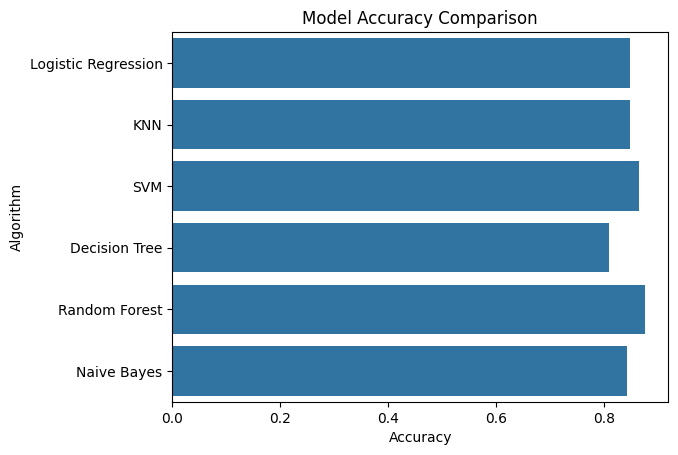

In [ ]:
# checking the accuracy of the all algorithms in barplot
sns.barplot(x='Accuracy', y='Algorithm', data=results)
plt.title("Model Accuracy Comparison")
plt.show()

**Conclusion**

In this project, different classification algorithms were applied to predict heart disease. The algorithms used include Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Decision Tree, Random Forest, and Naive Bayes. Each model was trained and tested using the dataset. The performance of the models was evaluated using accuracy. After comparing the results, Random Forest showed the highest accuracy among the models, making it the best performing algorithm for this dataset. Therefore, Random Forest can be considered the most effective model for predicting heart disease in this analysis.